In [1]:
import os
import sys
import subprocess
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from qiskit import qasm2, transpile
from qiskit.transpiler import CouplingMap

def get_active_qubits(circuit):
    active = set()
    for instruction in circuit.data:
        for qubit in instruction.qubits:
            active.add(circuit.find_bit(qubit).index)
    return sorted(active)

def get_metrics_averaged(qasm_path, num_seeds=5):
    qc = qasm2.load(qasm_path)
    active_qubits = get_active_qubits(qc)
    coupling = CouplingMap.from_heavy_hex(7)
    
    transpiled_depths = []
    swaps_list = []
    cx_counts = []
    
    for seed in range(42, 42 + num_seeds):
        qc_trans = transpile(
            qc, 
            coupling_map=coupling, 
            routing_method="sabre", 
            seed_transpiler=seed
        )
        swaps_list.append(sum(1 for instr in qc_trans.data if instr.operation.name == "swap"))
        transpiled_depths.append(qc_trans.depth())
        cx_counts.append(qc_trans.count_ops().get("cx", 0))
        
    return {
        "total_qubits": qc.num_qubits,
        "active_qubits": len(active_qubits),
        "active_list": active_qubits,
        "logical_depth": qc.depth(),
        "transpiled_depth": np.mean(transpiled_depths),
        "swaps": np.mean(swaps_list),
        "cx_count": np.mean(cx_counts)
    }

In [8]:
ORIGINAL_BENCHMARK = Path("benchmarks/bv_n10.qasm")
OUTPUT_DIR = Path("output")

initial_qc = qasm2.load(ORIGINAL_BENCHMARK)
total_qubits = initial_qc.num_qubits

results = []

baseline_metrics = get_metrics_averaged(ORIGINAL_BENCHMARK)
baseline_metrics["target_k"] = total_qubits
baseline_metrics["status"] = "Baseline"
results.append(baseline_metrics)

print(f"Baseline circuit loaded. Total qubits: {total_qubits}")
print("-" * 55)

for k in range(total_qubits - 1, 1, -1):
    print(f"Running CaQR for target k = {k}...")
    
    cmd = [
        sys.executable,
        "main.py",
        "--mode", "qs",
        "-b", str(ORIGINAL_BENCHMARK).replace("\\", "/"),
        "-k", str(k),
        "-v", "0"
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"   Execution failed for k={k}:\n{result.stderr}")
        continue
        
    output_qasm = OUTPUT_DIR / f"{ORIGINAL_BENCHMARK.stem}_reuse.qasm"
    
    if not output_qasm.exists():
        print(f"   Output file not found for k={k}")
        continue
        
    metrics = get_metrics_averaged(output_qasm)
    metrics["target_k"] = k
    metrics["status"] = "Success"
    results.append(metrics)
    
    print(f"   Target k={k} | Active={metrics['active_qubits']} | "
          f"Logical Depth={metrics['logical_depth']} | "
          f"Transpiled Depth={metrics['transpiled_depth']:.1f} | "
          f"Avg SWAPs={metrics['swaps']:.1f}")

df = pd.DataFrame(results)

Baseline circuit loaded. Total qubits: 10
-------------------------------------------------------
Running CaQR for target k = 9...
   Target k=9 | Active=9 | Logical Depth=17 | Transpiled Depth=23.2 | Avg SWAPs=5.8
Running CaQR for target k = 8...
   Target k=8 | Active=8 | Logical Depth=21 | Transpiled Depth=25.6 | Avg SWAPs=4.8
Running CaQR for target k = 7...
   Target k=7 | Active=7 | Logical Depth=25 | Transpiled Depth=28.2 | Avg SWAPs=3.6
Running CaQR for target k = 6...
   Target k=6 | Active=6 | Logical Depth=29 | Transpiled Depth=30.8 | Avg SWAPs=2.6
Running CaQR for target k = 5...
   Target k=5 | Active=5 | Logical Depth=33 | Transpiled Depth=34.0 | Avg SWAPs=1.8
Running CaQR for target k = 4...
   Target k=4 | Active=4 | Logical Depth=37 | Transpiled Depth=36.0 | Avg SWAPs=0.0
Running CaQR for target k = 3...
   Target k=3 | Active=3 | Logical Depth=41 | Transpiled Depth=40.0 | Avg SWAPs=0.0
Running CaQR for target k = 2...
   Target k=2 | Active=2 | Logical Depth=45 | Tran

In [5]:
df_display = df[[
    "target_k", 
    "active_qubits", 
    "logical_depth", 
    "transpiled_depth", 
    "swaps", 
    "cx_count"
]].copy()

df_display.columns = [
    "Target k", 
    "Active Qubits", 
    "Logical Depth", 
    "Transpiled Depth", 
    "Avg SWAPs", 
    "Avg CNOTs"
]

print("\n" + "="*60)
print("CaQR Target Qubit (k) Sweep Results:")
print("="*60)
df_display


CaQR Target Qubit (k) Sweep Results:


,Target k,Active Qubits,Logical Depth,Transpiled Depth,Avg SWAPs,Avg CNOTs
0,10,10,13,20.0,7.8,9.0
1,9,9,17,23.2,5.8,9.0
2,8,8,21,25.6,4.8,9.0
3,7,7,25,28.2,3.6,9.0
4,6,6,29,30.8,2.6,9.0
5,5,5,33,34.0,1.8,9.0
6,4,4,37,36.0,0.0,9.0
7,3,3,41,40.0,0.0,9.0
8,2,2,45,44.0,0.0,9.0


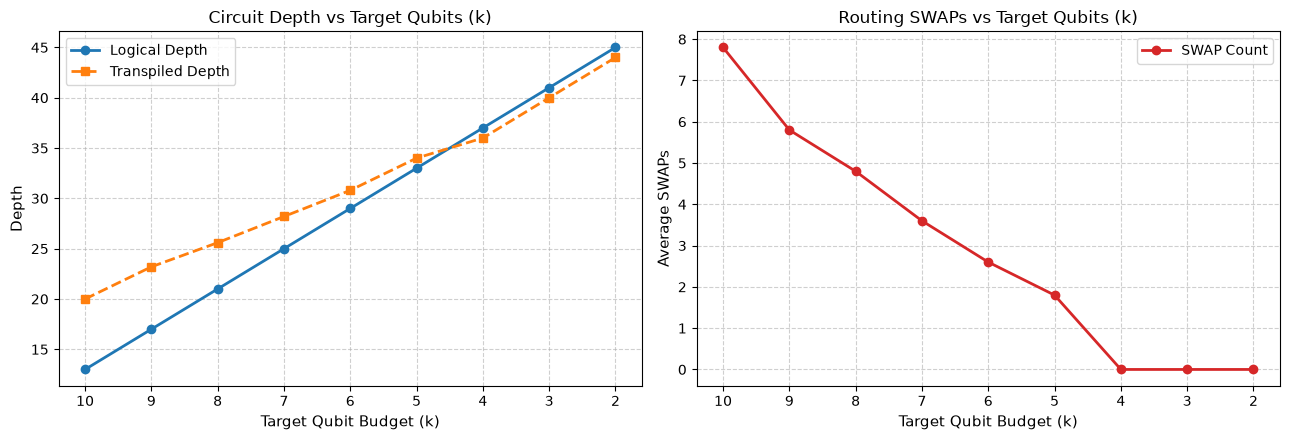

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(df["target_k"], df["logical_depth"], 'o-', color="tab:blue", linewidth=2, label="Logical Depth")
ax1.plot(df["target_k"], df["transpiled_depth"], 's--', color="tab:orange", linewidth=2, label="Transpiled Depth")
ax1.set_xlabel("Target Qubit Budget (k)", fontsize=11)
ax1.set_ylabel("Depth", fontsize=11)
ax1.set_title("Circuit Depth vs Target Qubits (k)", fontsize=12)
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.invert_xaxis()

ax2.plot(df["target_k"], df["swaps"], 'o-', color="tab:red", linewidth=2, label="SWAP Count")
ax2.set_xlabel("Target Qubit Budget (k)", fontsize=11)
ax2.set_ylabel("Average SWAPs", fontsize=11)
ax2.set_title("Routing SWAPs vs Target Qubits (k)", fontsize=12)
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

### Conclusion & Key Takeaways

* **Linear Qubit-Depth Trade-off:** Reducing the target qubit budget ($k$) leads to a linear increase in logical circuit depth ($\Delta \text{depth} = 4$ per qubit reduced). This increase stems directly from gate serialization on reused qubits.

* **Elimination of Routing Overhead:** As $k$ decreases, active qubits fit into a more compact subgraph of the Heavy-Hex topology. The average routing SWAP count drops steadily from **7.8** at $k=10$ down to **0.0** at $k \le 4$.

* **Transpiled vs. Logical Depth Convergence:** At lower qubit budgets ($k \le 4$), transpiled depth converges with logical depth. Removing SWAP gates eliminates topology-induced routing overhead entirely.

* **Preserved Two-Qubit Gate Count:** The CNOT count remains strictly constant (**9.0**) across all configurations, confirming that qubit reuse adds zero multi-qubit gate overhead.

* **Optimal Trade-off (Sweet Spot):** Setting **$k=4$** (or $k=5$) provides the optimal trade-off. It reduces the physical qubit requirement by up to **60%** and completely eliminates SWAP overhead while keeping circuit depth manageable.